In [1]:
import numpy as np
import matplotlib.pyplot as plt
import random
import isotp # thanks to Liz for figuring this out

In [2]:
from parsing_lib import frame_and_muid, populate_dict, populate_dict_panda, calculate_unique_message_id
from parsing_lib import return_all_messages_for_frame, return_all_frames_messages_for_muid_and_frame
from parsing_lib import return_frame_IDs_with_message_changes, return_frame_IDs_muids, return_unique_messages_for_frame
from parsing_lib import return_frame_IDs_muids_with_message_changes_in_timestamp_range, return_interesting_timestamps

In [4]:
lock = {}

In [5]:
populate_dict(lock, '/home/trh/Downloads/locking and unlocking patterns clean.csv')

In [6]:
for log in [lock]:
    calculate_unique_message_id(log)

In [7]:
lock_frames_muids = return_frame_IDs_muids(lock)

In [8]:
return_frame_IDs_with_message_changes(lock)

[[np.int64(54), 265],
 [np.int64(56), 2],
 [np.int64(326), 258],
 [np.int64(463), 15],
 [np.int64(603), 596],
 [np.int64(606), 35],
 [np.int64(737), 128],
 [np.int64(763), 205],
 [np.int64(764), 11],
 [np.int64(779), 665],
 [np.int64(780), 2],
 [np.int64(781), 2],
 [np.int64(782), 6],
 [np.int64(795), 142],
 [np.int64(796), 5],
 [np.int64(806), 128],
 [np.int64(879), 45],
 [np.int64(895), 15],
 [np.int64(914), 61],
 [np.int64(1029), 42],
 [np.int64(1041), 3],
 [np.int64(1044), 2],
 [np.int64(1048), 2],
 [np.int64(1049), 767],
 [np.int64(1092), 2],
 [np.int64(1264), 142],
 [np.int64(1280), 2],
 [np.int64(1317), 2],
 [np.int64(1321), 2]]

In [9]:
return_unique_messages_for_frame(log,56)

[array([  2,   1,   0,   0,  48,  58, 130, 212]),
 array([  2,   1,   0,   0, 128,  58, 130, 212])]

0x418
0x526
0x529
0x405


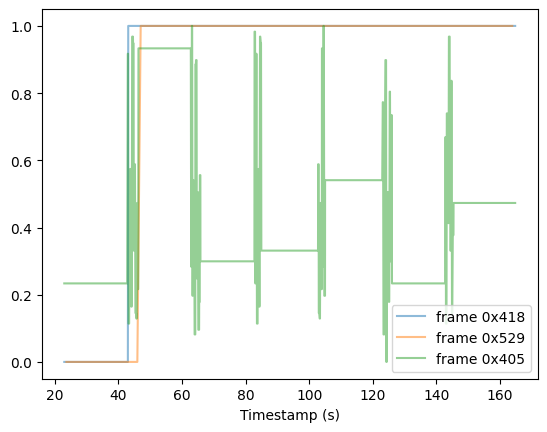

In [43]:
# test individual frame IDs via plotting
log = lock
for frame_id in [ 1048, 1318, 1321, int('405',16)]:
    print(hex(frame_id))
    indices = np.argwhere(log['ids'] == frame_id)[:,0]
    if(len(indices)):
        norm_vals = log['messages_unique_ids'][indices].astype(float)
        norm_vals -= norm_vals.min()
        norm_vals /= norm_vals.max()
        plt.plot(log['timestamps'][indices]/1e6,norm_vals,label=f'frame {hex(frame_id)}', alpha=0.5)
plt.xlabel('Timestamp (s)')
plt.legend()
plt.show()

0x38
0x411
0x405


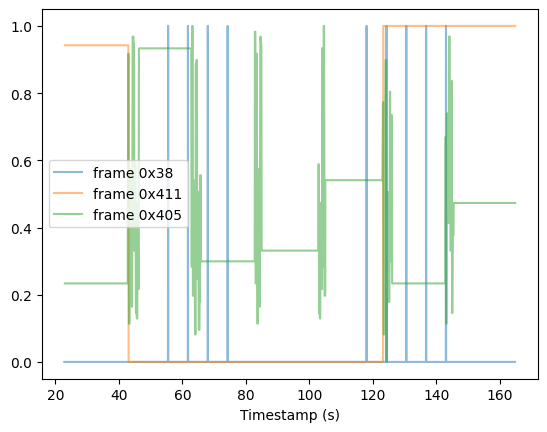

In [10]:
# test individual frame IDs via plotting
log = lock
for frame_id in [int('038', 16), int('411',16), int('405',16)]:
    print(hex(frame_id))
    indices = np.argwhere(log['ids'] == frame_id)[:,0]
    if(len(indices)):
        norm_vals = log['messages_unique_ids'][indices].astype(float)
        norm_vals -= norm_vals.min()
        norm_vals /= norm_vals.max()
        plt.plot(log['timestamps'][indices]/1e6,norm_vals,label=f'frame {hex(frame_id)}', alpha=0.5)
plt.xlabel('Timestamp (s)')
plt.legend()
plt.show()

0x2fc
0x31c
0x405


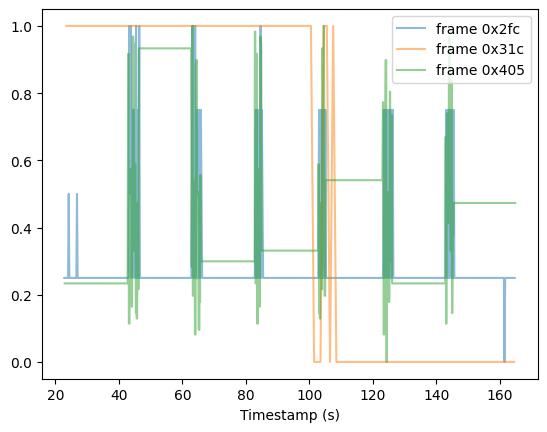

In [35]:
# test individual frame IDs via plotting
log = lock
for frame_id in [ 764, 796, int('405',16)]: #  463, 606, 782, 895
    print(hex(frame_id))
    indices = np.argwhere(log['ids'] == frame_id)[:,0]
    if(len(indices)):
        norm_vals = log['messages_unique_ids'][indices].astype(float)
        norm_vals -= norm_vals.min()
        norm_vals /= norm_vals.max()
        plt.plot(log['timestamps'][indices]/1e6,norm_vals,label=f'frame {hex(frame_id)}', alpha=0.5)
plt.xlabel('Timestamp (s)')
plt.legend()
plt.show()

In [25]:
indices = np.argwhere(lock['ids'] == 1029)[:,0]
timestamps = lock['timestamps'][indices][:-1][np.diff(lock['messages_unique_ids'][indices]) != 0]
# timestamp_range_1 = [0,10000000]
frame_list_per_timestamp = []
for timestamp in timestamps:
    print(timestamp)
    timestamp_range = [timestamp-500000,timestamp+500000]
    frame_muid_lists = return_frame_IDs_muids_with_message_changes_in_timestamp_range(lock,timestamp_range,only_within_range=False)
    frame_list_per_timestamp.append([item.frame_id for item in frame_muid_lists])

42766151
43021099
43365826
43565998
43966081
44165911
44565921
44766051
44965996
45201168
45566156
45766158
45976212
46211152
62767708
62987620
63182603
63372787
63582748
63832581
64167715
64367772
64567827
64767769
64977747
65367766
65567854
65767874
82769555
82969566
83169502
83424313
83769567
83969588
84169665
84374487
84604611
84844537
102771283
102971417
103171465
103386284
103596119
103971386
104171470
104371475
104591711
104971662
122972967
123217930
123572947
123772949
124173088
124373053
124773125
124973105
125173098
125408101
125773050
125973357
142774562
142974725
143174680
143385909
143584664
143819601
144174739
144374733
144574704
144784789
144989775
145374878


In [27]:
for frame_id in frame_list_per_timestamp[0]:
    occurrences = [1 for timestamp_list in frame_list_per_timestamp if frame_id in timestamp_list]
    print(len(occurrences))

print(frame_list_per_timestamp[0])

72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
72
36
69
70
68
68
66
67
68
70
67
69
[np.int64(55), np.int64(56), np.int64(57), np.int64(139), np.int64(197), np.int64(255), np.int64(327), np.int64(328), np.int64(329), np.int64(604), np.int64(605), np.int64(731), np.int64(738), np.int64(739), np.int64(740), np.int64(765), np.int64(766), np.int64(780), np.int64(781), np.int64(782), np.int64(782), np.int64(782), np.int64(782), np.int64(796), np.int64(797), np.int64(798), np.int64(807), np.int64(808), np.int64(809), np.int64(915), np.int64(916), np.int64(934), np.int64(938), np.int64(961), np.int64(962), np.int64(963), np.int64(992), np.int64(993), np.int64(994), np.int64(997), np.int64(998), np.int64(1025), np.int64(1026), np.int64(1027), np.int64(1032), np.int64(1034), np.int64(1036), np.int

In [14]:
hex(1048)

'0x418'